## Importing PyTorch and other dependencies
Importing PyTorch and matplot for data visualization.

In [ ]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.12.0+cu126'

## Agnostic Code Setup

In [ ]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


For Linear Regression dataset 

In [ ]:
import pandas as pd
import torch

df = pd.read_csv(r'./Resources/assignment-data.csv')
df.head(5) #first five data point

## Data Preparation 

### Data loading
Data loading is done by using pandas library.

In [ ]:
import pandas as pd
import torch

df = pd.read_csv(r'../4_Linear_Regression_using_PyTorch/Resources/linear-regression-data1.csv' )
df.head(5) #first five data point

,x,y
0,0.0,2.00
1,0.2,2.12
2,0.4,2.48
3,0.6,3.08
4,0.8,3.92


In [ ]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

## Changing shape of the data for PyTorch 

Pytorch uses Tenors so we need to convert our data into the required multidimensional tensor data structure. 

In order to convert the 1 D vector consisting of scalar data points into tensors, We need to  unsqueeze the data by using the unsqueeze function from pytorch.
Here the output shape of the data shows that its been converted into a tensor of shape (50, 1);where there is 50 data points and a 1 column.

In [ ]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([50, 1])
torch.Size([50, 1])


## Splitting data 
We need two data sets; one for training our model and other to test the model, so we split the dataset into two parts.

In [ ]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

## Visualization of training data
The dataset is visualized as follows.

In [ ]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 20});


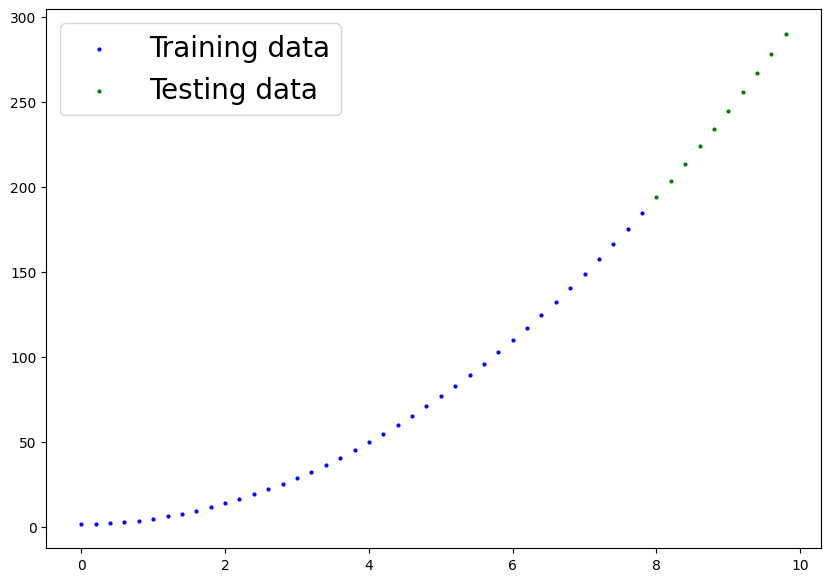

In [ ]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

Here, the blue dots represent the training dataset and the green dots represent the testing data. The coloured point on the curve here shows that the data has been split correctly into 80% training data and 20% testing data.

</br>

## **Note:**
Its important to note that the data is in a curve and not a line. It shows **quadratic nature.**

## Algorithm Selection
Lets first try Linear Regression to see how the model behaves when its been fed a curve and not a straight line.

### Model and Forward Pass

In [ ]:
import torch
from torch import nn

# Define model
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(
            in_features=1,
            out_features=1,
            bias=True
        )

    def forward(self, x):
        return self.linear(x)

In [ ]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
print(model_0.weights.dtype)
print(model_0.bias.dtype)

torch.float32
torch.float32


In [ ]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[2.8223],
        [2.8897],
        [2.9570],
        [3.0243],
        [3.0917]])

In [ ]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[2.8223],
        [2.8897],
        [2.9570],
        [3.0243],
        [3.0917],
        [3.1590],
        [3.2264],
        [3.2937],
        [3.3610],
        [3.4284]])


### Predictions without training

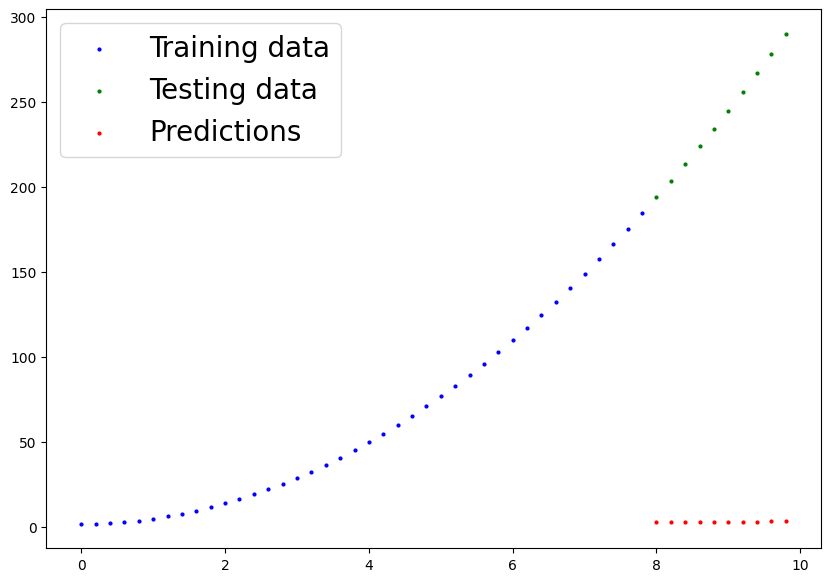

In [ ]:
plot_predictions(predictions=y_preds)

In [ ]:
# Loss Function Selection
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))


In [ ]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 100

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Caculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 62.17809295654297 | MAE Test Loss: 237.13754272460938 
Epoch: 10 | MAE Train Loss: 60.557098388671875 | MAE Test Loss: 233.56655883789062 
Epoch: 20 | MAE Train Loss: 58.93609619140625 | MAE Test Loss: 229.9955596923828 
Epoch: 30 | MAE Train Loss: 57.315101623535156 | MAE Test Loss: 226.424560546875 
Epoch: 40 | MAE Train Loss: 55.694091796875 | MAE Test Loss: 222.853515625 
Epoch: 50 | MAE Train Loss: 54.073097229003906 | MAE Test Loss: 219.2825164794922 
Epoch: 60 | MAE Train Loss: 52.45208740234375 | MAE Test Loss: 215.71151733398438 
Epoch: 70 | MAE Train Loss: 50.831092834472656 | MAE Test Loss: 212.14053344726562 
Epoch: 80 | MAE Train Loss: 49.21009063720703 | MAE Test Loss: 208.5695343017578 
Epoch: 90 | MAE Train Loss: 47.637943267822266 | MAE Test Loss: 205.05331420898438 


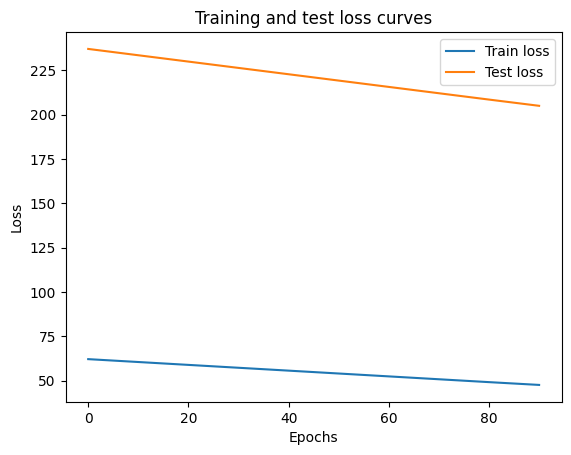

In [ ]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

The loss function obtained show a lot of loss in testing and training. Changing the epochs doesn't improve it significantly either.

In [ ]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: 0.7, bias: 0.3")

The model learned the following values for weights and bias:
OrderedDict({'weights': tensor([4.2199]), 'bias': tensor([1.1033])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


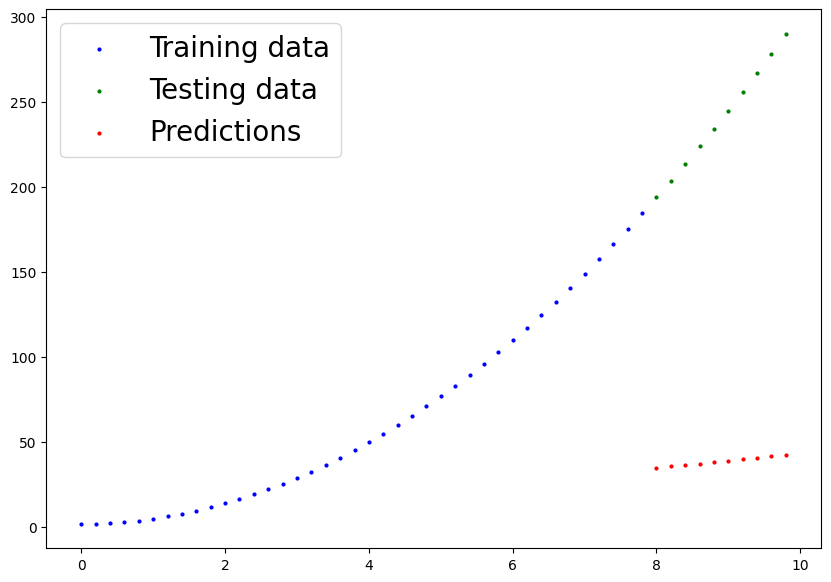

In [ ]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

## Result of second dataset 
The predicions made by the model is completely off. This can be discerned from the curve where prdicted values represented by the red dots are nowhere close to the green dots (testing data). Unfortunately this is the case even after increasing the epochs.

### For assigment data2 set
